# Ресурсы

## 1.Численность специалистов госсектора, занимающихся решением проблемы

indicator_category == '6. Специалисты по охране детства'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные

In [2]:
# Загружаем только необходимые колонки
df = pd.read_excel('data_orphans_127_v20241218.xlsx', 
                   usecols=['year', 'region', 'indicator_category', 'dimension', 
                            'main_level', 'indicator', 'indicator_value'])

# Быстро проверим размер
print(df.shape)
print(df.head(2))

(864205, 7)
   year             region                                 indicator_category  \
0  2014  Республика Адыгея  1. Учет и устройство детей, оставшихся без поп...   
1  2014  Республика Адыгея  1. Учет и устройство детей, оставшихся без поп...   

  dimension                                         main_level  \
0     всего  детей выявлено и учтено, всего, на конец отчет...   
1     всего  детей выявлено и учтено, всего, на конец отчет...   

                                           indicator  indicator_value  
0  детей, оставшихся неустроенными к началу отчет...                1  
1       детей, выявленных и учтенных за отчетный год              172  


In [7]:
df_about_spec_rows = df[(df['indicator_category'] == '6. Специалисты по охране детства') & (df['dimension'] == 'всего') & \
                        df['main_level'] == 'общая численность специалистов по охране детства'
                        ]
print("Уникальные dimension:", df_about_spec_rows['dimension'].unique())
print("Уникальные main_level:", df_about_spec_rows['main_level'].unique())



Уникальные dimension: <StringArray>
[]
Length: 0, dtype: str
Уникальные main_level: <StringArray>
[]
Length: 0, dtype: str


C:\Users\БЛАШУЛЯ\AppData\Local\Temp\ipykernel_10832\2103768664.py:1: Pandas4Warning: 'and' operations between boolean dtype and str are deprecated and will raise in a future version. Explicitly cast the strings to a boolean dtype before operating instead.
  df_about_spec_rows = df[(df['indicator_category'] == '6. Специалисты по охране детства') & (df['dimension'] == 'всего') & \


In [8]:
df_about_spec_rows = df[(df['indicator_category'] == '6. Специалисты по охране детства') & (df['dimension'] == 'всего') & \
                        (df['main_level'] == 'общая численность специалистов по охране детства')
]

specs_by_year = df_about_spec_rows.groupby('year')['indicator_value'].sum().reset_index()

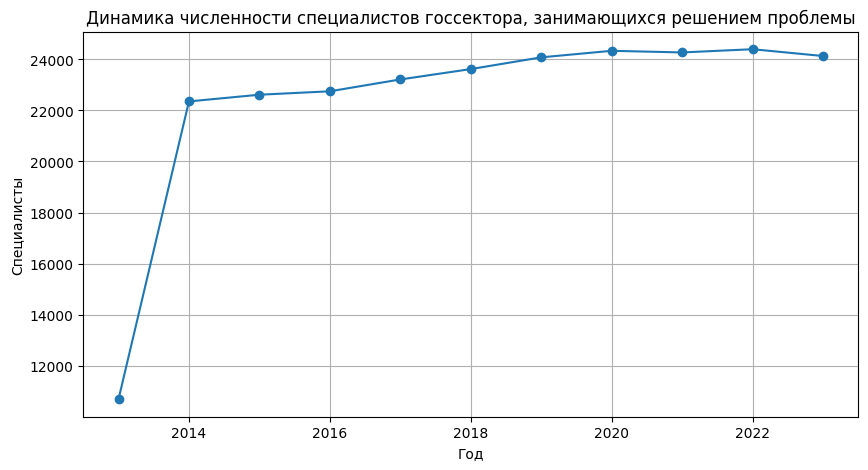

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
"""Горизонт - год, вертикаль - число сирот"""
plt.plot(specs_by_year['year'], specs_by_year['indicator_value'], marker='o', linestyle='-')
plt.title('Динамика численности специалистов госсектора, занимающихся решением проблемы')
plt.xlabel('Год')
plt.ylabel('Специалисты')
plt.grid(True)
plt.show()

## 2.Количество организаций, занимающихся выявлением и устройством сирот

In [ ]:
print(df['main_level'].unique())

<StringArray>
[                                                                                                                                                                                                                                   'детей выявлено и учтено, всего, на конец отчетного года',
                                                                                                                                                                                                                                               'детей, выявленных и учтенных за отчетный год',
                                                                                                                                                                                                                                                                                       'main',
                                                                                                                             

In [9]:
print(df['indicator'].unique())

<StringArray>
[                                                                                                                                                                                                                                   'детей, оставшихся неустроенными к началу отчетного года',
                                                                                                                                                                                                                                               'детей, выявленных и учтенных за отчетный год',
                                                                                                                                                                                                                                                                                'детей-сирот',
                                                                                                                             

In [10]:
df_organizations = df[
    (df['indicator_category'] == '6. Специалисты по охране детства') & (df['dimension'] == 'всего') \
    & (df['main_level'].str.contains('уполномоченных организаций', na=False))
]

orgs_by_year = df_organizations.groupby('year')['indicator_value'].sum().reset_index()

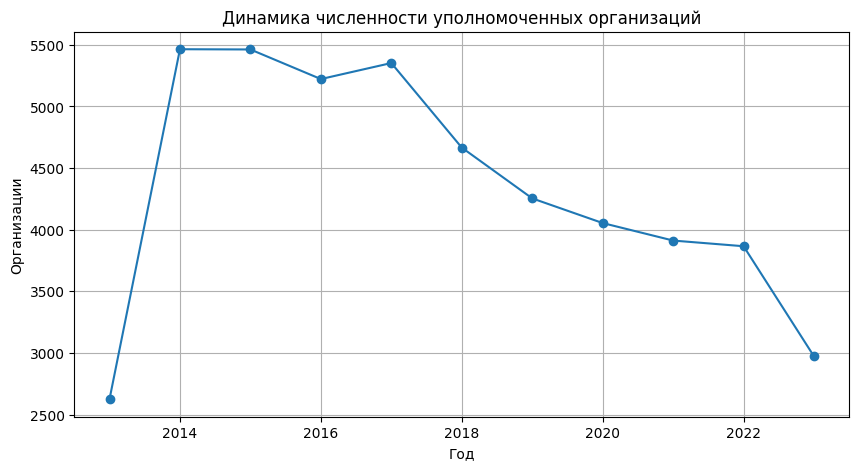

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
"""Горизонт - год, вертикаль - число сирот"""
plt.plot(specs_by_year['year'], orgs_by_year['indicator_value'], marker='o', linestyle='-')
plt.title('Динамика численности уполномоченных организаций')
plt.xlabel('Год')
plt.ylabel('Организации')
plt.grid(True)
plt.show()